# Sampel 1, Motif Pinggir

In [96]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [97]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

## Latar Belakang

array([  0, 255], dtype=uint8)

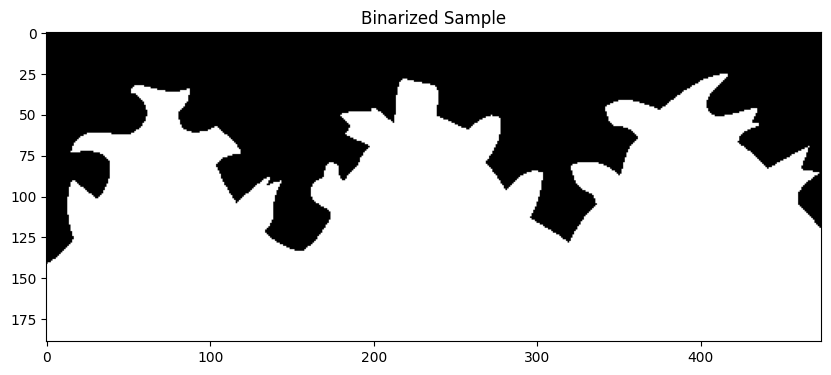

In [98]:
background = cv2.imread('sampel-1_motif-pinggir-a.png')
background_binary = binarize(background)

plt.figure(figsize=(10,10))
plt.imshow(background_binary, cmap='gray')
plt.title("Binarized Sample")

np.unique(background_binary)

array([  0, 255], dtype=uint8)

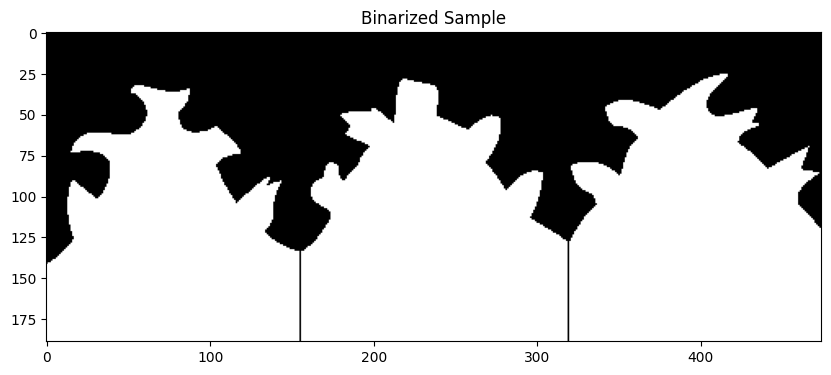

In [99]:
back_chopped = cv2.imread('sampel-1_motif-pinggir-aa.png')
back_chopped_binary = binarize(back_chopped)

height, width = back_chopped_binary.shape

plt.figure(figsize=(10,10))
plt.imshow(back_chopped_binary, cmap='gray')
plt.title("Binarized Sample")

np.unique(back_chopped_binary)

3

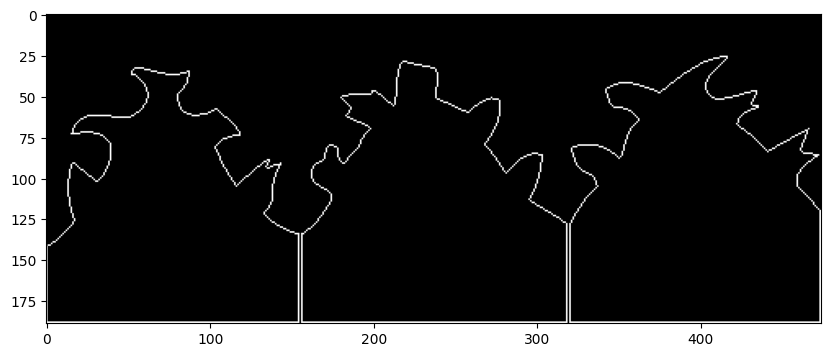

In [100]:
back_contours = extractContours(back_chopped_binary)

back_contour_map = createContourMap(background_binary.shape, back_contours)

plt.figure(figsize=(10, 10))
plt.imshow(back_contour_map, cmap='gray')

len(back_contours)

In [101]:
back_contours_interpolated = interpolateContours(back_contours, 100)
back_mean_shape, back_contours_aligned = processGPA(back_contours_interpolated)

3.7653060554441277e-08


In [102]:
back_procrustes_distances = procrustesDistances(back_mean_shape, back_contours_aligned)
summarizeData(back_procrustes_distances, "Procrustes Analysis")

back_procrustes_distances

DATA SUMMARY of [Procrustes Analysis]:
Num     : 3
Mean    : 0.0685
SD      : 0.0092
SD rel  : 13.48%
Median  : 0.0702
MAD     : 0.0086
MAD rel : 12.30%
Min     : 0.0564
Max     : 0.0789



array([0.07888436, 0.05644885, 0.07024243])

In [103]:
back_contour_areas = contourAreas(back_contours)
summarizeData(np.sqrt(back_contour_areas), "Big Variant Rooted Areas")

back_contour_areas

DATA SUMMARY of [Big Variant Rooted Areas]:
Num     : 3
Mean    : 133.5446
SD      : 4.1657
SD rel  : 3.12%
Median  : 136.2920
MAD     : 0.3920
MAD rel : 0.29%
Min     : 127.6577
Max     : 136.6839



array([16296.5, 18575.5, 18682.5])

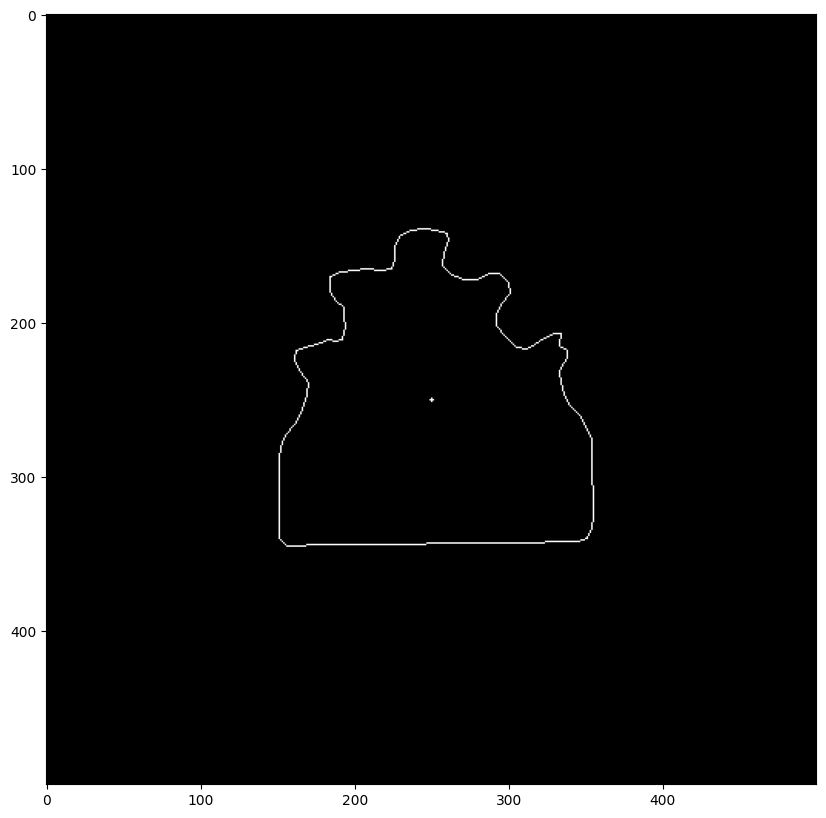

In [104]:
back_size_factor = 1000

back_mean_shape_binary = drawStandardizedContour((500, 500), back_mean_shape, back_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(back_mean_shape_binary, cmap='gray')

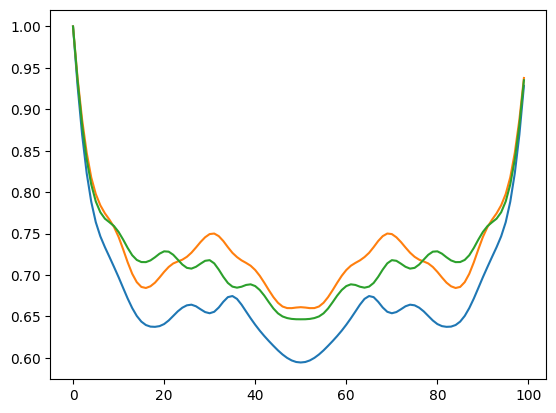

In [105]:
for shape in back_contours_aligned:
    sns.lineplot(testRotationalSymmetry(shape))

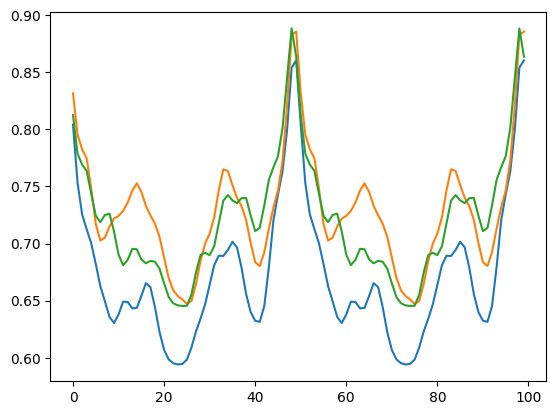

In [106]:
for shape in back_contours_aligned:
    sns.lineplot(testReflectionalSymmetry(shape))

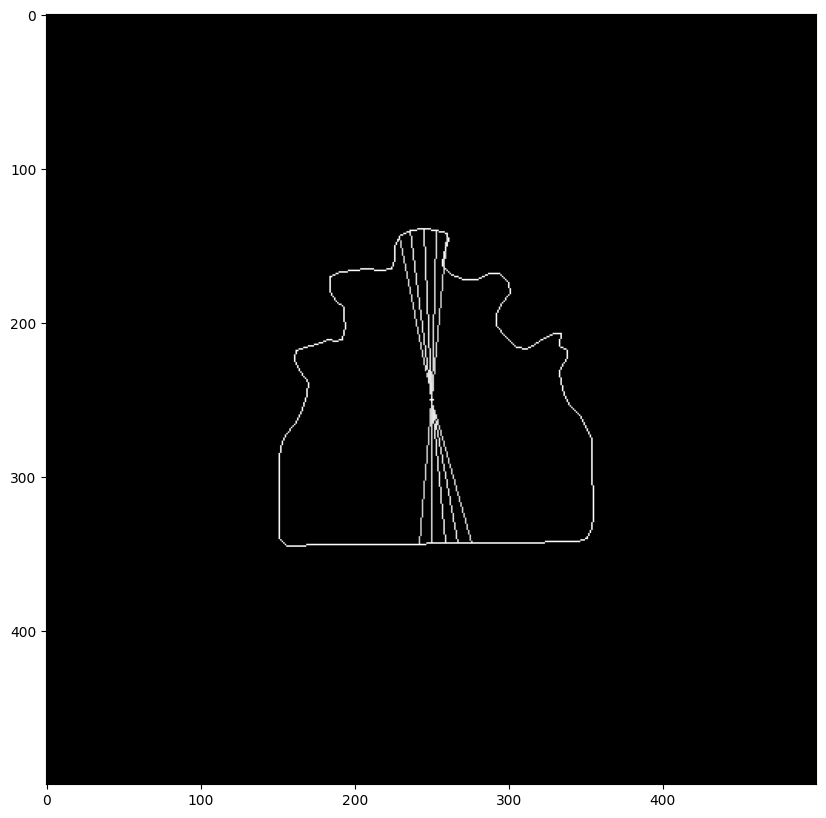

In [107]:
back_mean_shape_reflectional_symmetry = drawReflectionalSymmetryAxis(
    (500, 500), back_mean_shape, back_size_factor, minimum_symmetricity=0.8
)

plt.figure(figsize=(10, 10))
plt.imshow(back_mean_shape_reflectional_symmetry, cmap='gray')

In [108]:
back_num_label, back_labeled_map, back_stats, back_centroids = cv2.connectedComponentsWithStats(back_chopped_binary)

back_centroids = back_centroids[1:]

In [109]:
back_horizontal_distances = []

for i in range(0, len(back_centroids) - 1):
    for j in range(i + 1, len(back_centroids)):
        back_horizontal_distance = abs(back_centroids[i][0] - back_centroids[j][0])
        back_horizontal_distances.append(back_horizontal_distance)

back_horizontal_distances = np.sort(back_horizontal_distances)[:len(back_centroids) - 1]

back_distance_median = summarizeData(back_horizontal_distances, "Background Horizontal Distances")['median']

back_horizontal_distances

DATA SUMMARY of [Background Horizontal Distances]:
Num     : 2
Mean    : 160.0212
SD      : 0.9764
SD rel  : 0.61%
Median  : 160.0212
MAD     : 0.9764
MAD rel : 0.61%
Min     : 159.0448
Max     : 160.9977



array([159.04481607, 160.99767551])

In [110]:
back_vertical_distances = []

for i in range(0, len(back_centroids) - 1):
    for j in range(i + 1, len(back_centroids)):
        back_vertical_distance = abs(back_centroids[i][1] - back_centroids[j][1])
        back_vertical_distances.append(back_vertical_distance)

back_vertical_distances = np.sort(back_vertical_distances)[:len(back_centroids) - 1]

summarizeData(back_vertical_distances, "Background Vertical Distances")

back_vertical_distances

DATA SUMMARY of [Background Vertical Distances]:
Num     : 2
Mean    : 2.9026
SD      : 0.4817
SD rel  : 16.59%
Median  : 2.9026
MAD     : 0.4817
MAD rel : 16.59%
Min     : 2.4210
Max     : 3.3843



array([2.42098523, 3.38431103])

## Latar Depan (Umum)

(189, 474)


array([  0, 255], dtype=uint8)

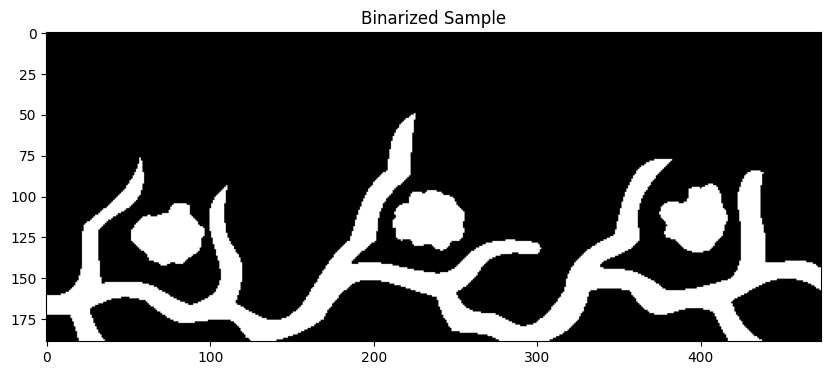

In [111]:
branches = cv2.imread('sampel-1_motif-pinggir-b.png')
flower = cv2.imread('sampel-1_motif-pinggir-c.png', 0)
branches_binary = binarize(branches)
flower_binary = binarize(flower)

print(flower_binary.shape)

foreground_binary = branches_binary | flower_binary

plt.figure(figsize=(10,10))
plt.imshow(foreground_binary, cmap='gray')
plt.title("Binarized Sample")

np.unique(foreground_binary)

In [112]:
area_occupancy = getAreaOccupancy(foreground_binary, background_binary)

print(f"Occupancy: {(area_occupancy*100):.2f}%")

Occupancy: 29.93%


True

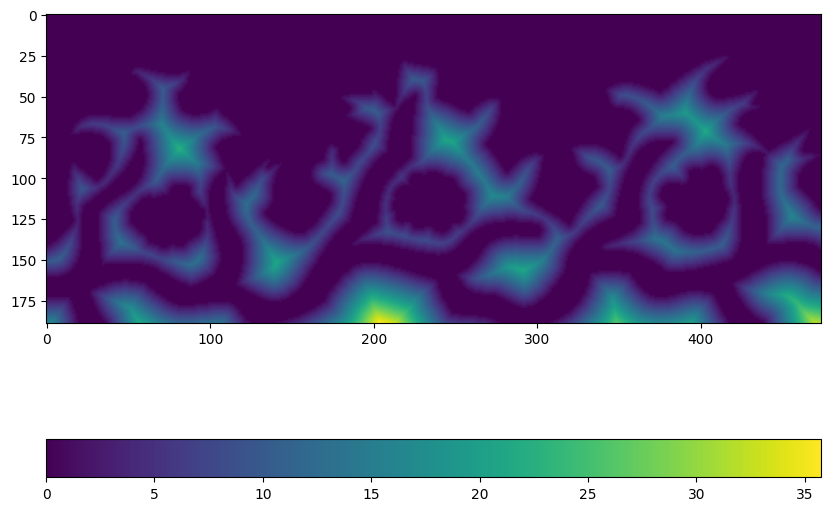

In [113]:
distance_map = cv2.distanceTransform(background_binary & ~foreground_binary, cv2.DIST_L2, 5)

plt.figure(figsize=(10, 10))
plt.imshow(distance_map)
plt.colorbar(orientation='horizontal')

cv2.imwrite('sampel-1_motif-pinggir-depan.png', background_binary & ~foreground_binary)

DATA SUMMARY of [Void Distances]:
Num     : 38305
Mean    : 6.9844
SD      : 5.3011
SD rel  : 75.90%
Median  : 5.7938
MAD     : 2.9938
MAD rel : 51.67%
Min     : 1.0000
Max     : 35.7535



{'num': 38305,
 'mean': 6.9844,
 'sd': 5.3010716,
 'median': 5.7938,
 'mad': 2.9938,
 'min': 1.0,
 'max': 35.753494}

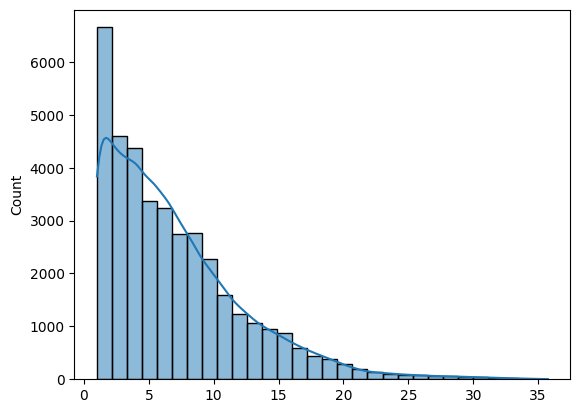

In [114]:
distances = distance_map.flatten()
distances = distances[distances > 0]

sns.histplot(distances, kde=True, bins=30)
# sns.kdeplot(distances)
# sns.stripplot(distances, jitter=0.5)

summarizeData(distances, "Void Distances")

## Cabang-Cabang

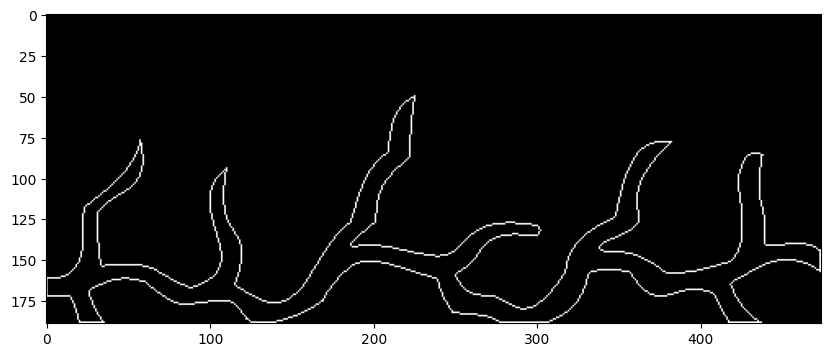

In [115]:
branch_contours = extractContours(branches_binary)

branch_contour_map = createContourMap(branches_binary.shape, branch_contours)


plt.figure(figsize=(10, 10))
plt.imshow(branch_contour_map, cmap='gray')

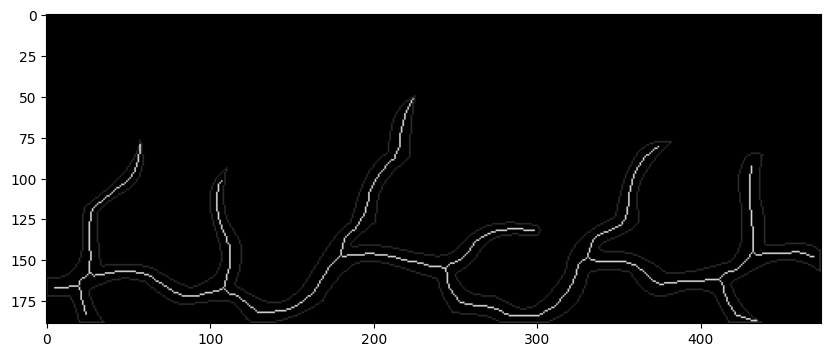

In [116]:
branches_smooth_binary = smoothBinary(branches_binary)
branch_skeleton_image, branch_skan = skeletonize(branches_smooth_binary)

plt.figure(figsize=(10, 10))
plt.imshow(branch_skeleton_image + branch_contour_map * 0.2, cmap='gray')

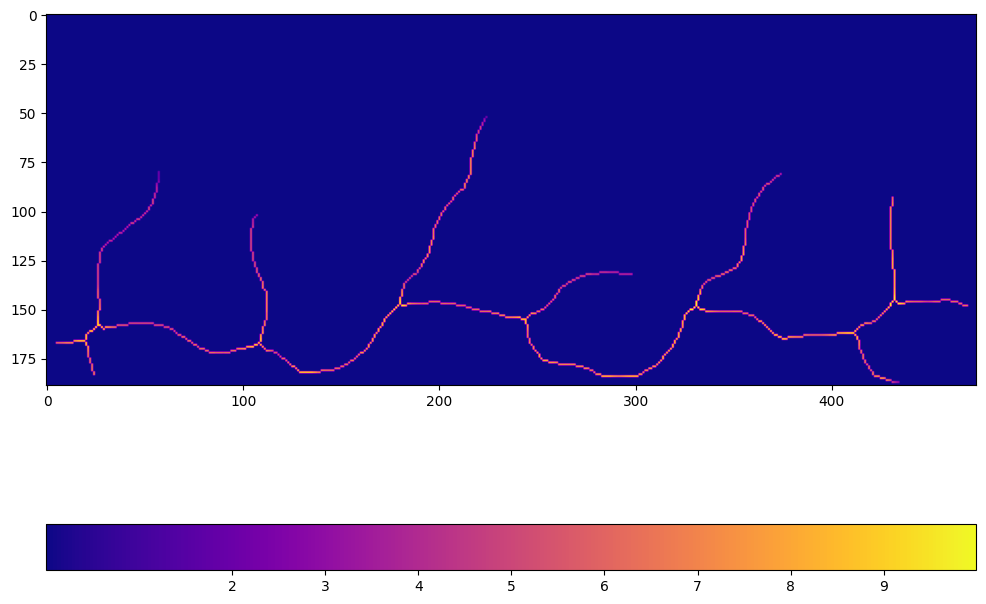

In [117]:
branch_thickness_map = mapThickness(branch_skeleton_image, branches_binary, 5)
branch_thickness = branch_thickness_map.flatten()
branch_thickness = branch_thickness[branch_thickness > 0]

plt.figure(figsize=(12, 12))
plt.imshow(branch_thickness_map, cmap='plasma')
colorbar = plt.colorbar(orientation='horizontal')
colorbar.set_ticks(range(int(min(branch_thickness)), int(max(branch_thickness)) + 1, 1))


DATA SUMMARY of [Branch Thickness]:
Num     : 977
Mean    : 6.6775
SD      : 1.3919
SD rel  : 20.84%
Median  : 6.5907
MAD     : 0.8031
MAD rel : 12.19%
Min     : 2.0000
Max     : 9.9938



<Axes: ylabel='Count'>

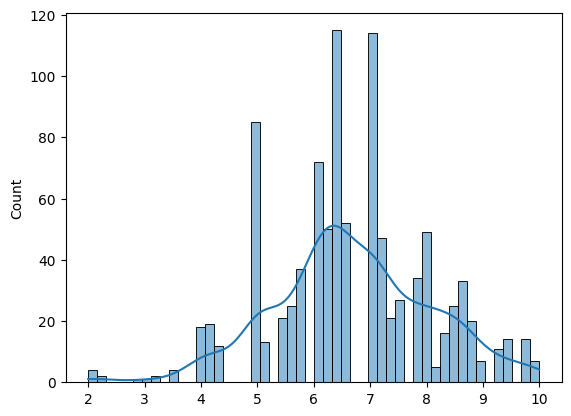

In [118]:
summarizeData(branch_thickness, "Branch Thickness")

# plt.figure(figsize=(10, 10))
sns.histplot(branch_thickness, kde=True, bins=50)

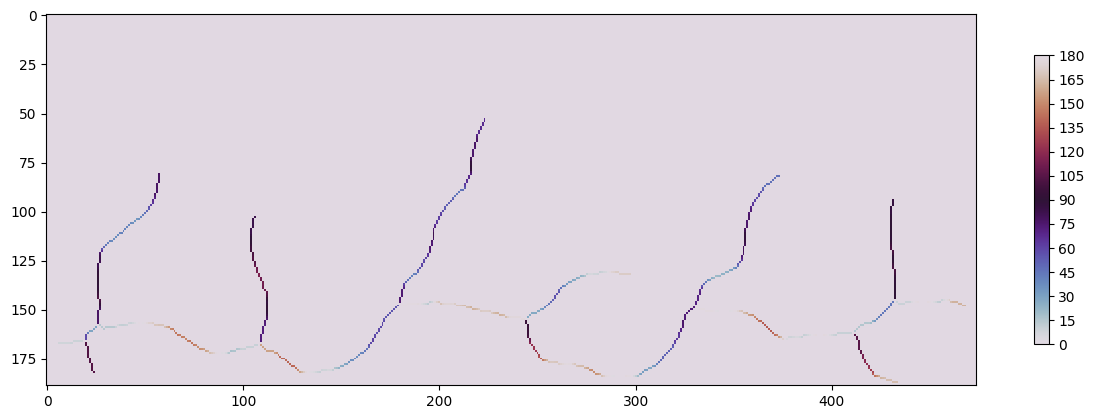

In [119]:
branch_orientation_map = np.rad2deg(mapBranchOrientation(branch_skeleton_image, branch_skan, 15))
branch_orientation_map_test = (branch_orientation_map + 0)
branch_orientation_map_test[np.isnan(branch_orientation_map_test)] = 0

plt.figure(figsize=(15, 15))
plt.imshow(branch_orientation_map_test, cmap='twilight', vmin=0, vmax=180, interpolation='nearest')
colorbar = plt.colorbar(shrink=0.25)

colorbar.set_ticks(range(0, 181, 15))

# np.unique(branch_orientation_map)

Text(0.5, 1.0, 'Branch Orientations')

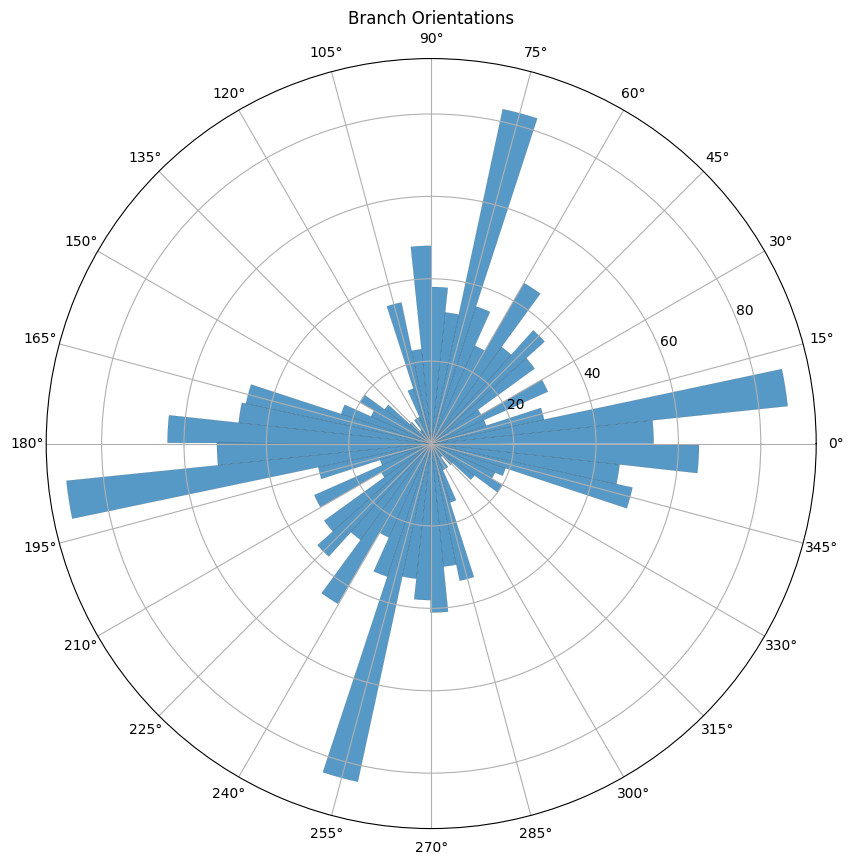

In [120]:

branch_orientations = branch_orientation_map[~np.isnan(branch_orientation_map)]
branch_orientations_repeated = np.concatenate((branch_orientations, branch_orientations + 180))

plt.figure(figsize=(10,10))
# plt.xticks(range(0, 361, 15))
ax = plt.axes(projection="polar")
ax.set_xticks(np.arange(0, np.pi*2, np.pi/12))
sns.histplot(branch_orientations_repeated / 180 * np.pi, ax=ax, bins=60)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Branch Orientations")
# np.unique(branch_orientations_repeated)

d:\Adri\Adri Doc\KIR\OPSI 2026\Analisis Sampel\Sampel 1\utils.py:446: RuntimeWarning: invalid value encountered in arccos
  curvatures[window_size // 2:-(window_size // 2)] = np.arccos(


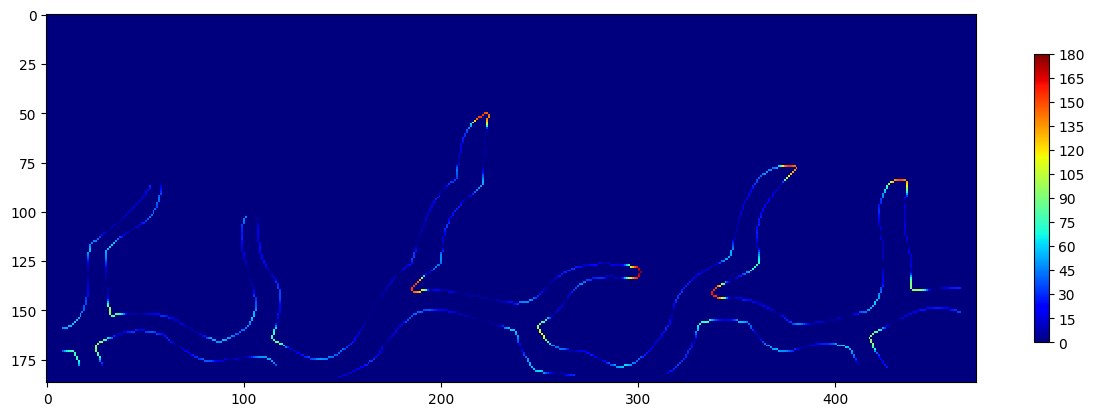

In [121]:
branch_contour_map_peeled = branch_contour_map[1:-1, 1:-1]

branch_contour_skeleton_image, branch_contour_skan = skeletonize(branch_contour_map_peeled)

branch_contour_curvature_map = mapBranchCurvature(branch_contour_skeleton_image, branch_contour_skan, 15)

branch_contour_curvature_map_test = branch_contour_curvature_map * 1
branch_contour_curvature_map_test[np.isnan(branch_contour_curvature_map_test)] = 0

plt.figure(figsize=(15, 15))
plt.imshow(branch_contour_curvature_map_test / np.pi * 180, cmap='jet', vmin=0, vmax=180, interpolation='nearest')
colorbar = plt.colorbar(shrink=0.25)
colorbar.set_ticks(range(0, 181, 15))

<Axes: ylabel='Count'>

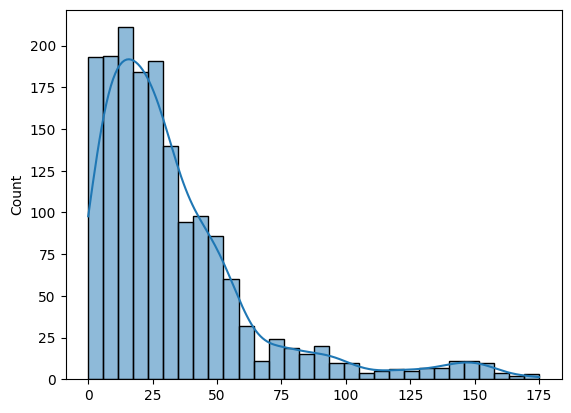

In [122]:
sns.histplot(branch_contour_curvature_map[~np.isnan(branch_contour_curvature_map)] / np.pi * 180, kde=True, bins=30)



## Bunga-Bunga

In [123]:
num_flower, flower_map, flower_stats, flower_centroids = cv2.connectedComponentsWithStats(flower_binary)



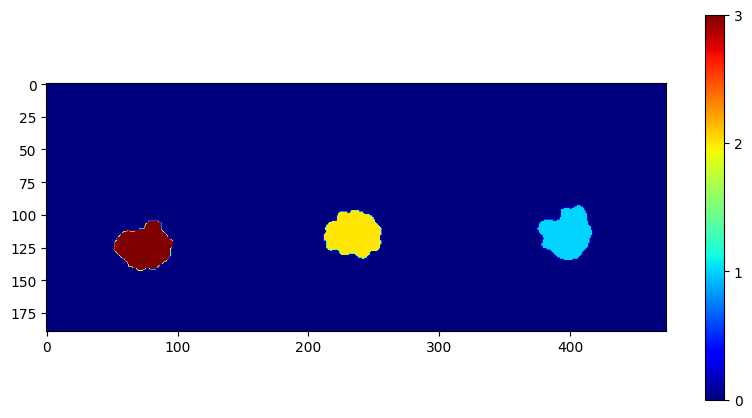

In [124]:
showLabeledMap(flower_map, True)

flower_centroids = flower_centroids[1:]

In [125]:
flower_center_distances = []
flower_orientation_distances = []

for i in range(0, len(flower_centroids) - 1):
    for j in range(i + 1, len(flower_centroids)):
        flower_center_distance = getNeighborCenterDistance(flower_centroids, (i, j))
        flower_center_distances.append(flower_center_distance)
        flower_orientation_distance = getNeighborOrientationDistance(flower_centroids, (i, j))
        flower_orientation_distances.append(flower_orientation_distance)

flower_center_distances = np.sort(flower_center_distances)[:len(flower_centroids) - 1]
flower_orientation_distances = np.array(flower_orientation_distances) / np.pi * 180

flower_distance_median = summarizeData(flower_center_distances, "Flower Center Distances")['median']

DATA SUMMARY of [Flower Center Distances]:
Num     : 2
Mean    : 161.3334
SD      : 1.5897
SD rel  : 0.99%
Median  : 161.3334
MAD     : 1.5897
MAD rel : 0.99%
Min     : 159.7437
Max     : 162.9231



In [126]:
summarizeData(flower_orientation_distances, "Flower Orientation Distances")

DATA SUMMARY of [Flower Orientation Distances]:
Num     : 3
Mean    : 178.2071
SD      : 1.3235
SD rel  : 0.74%
Median  : 178.2178
MAD     : 1.6049
MAD rel : 0.90%
Min     : 176.5809
Max     : 179.8227



{'num': 3,
 'mean': 178.2070996823156,
 'sd': 1.3234835852528062,
 'median': 178.2177504906701,
 'mad': 1.6049272765327203,
 'min': 176.58087078907383,
 'max': 179.82267776720283}

In [127]:
summarizeData([back_distance_median, flower_distance_median], "Background and Flower Motif Difference")

DATA SUMMARY of [Background and Flower Motif Difference]:
Num     : 2
Mean    : 160.6773
SD      : 0.6561
SD rel  : 0.41%
Median  : 160.6773
MAD     : 0.6561
MAD rel : 0.41%
Min     : 160.0212
Max     : 161.3334



{'num': 2,
 'mean': 160.67732317876565,
 'sd': 0.6560773906669226,
 'median': 160.67732317876565,
 'mad': 0.6560773906669226,
 'min': 160.02124578809872,
 'max': 161.33340056943257}

In [128]:
flower_from_centroid_x = []
flower_from_centroid_y = []
back_id_for_flower = []

for i in range(num_flower - 1):
    for j in range(back_num_label - 1):
        flower_from_centroid_x.append(abs(flower_centroids[i, 0] - back_centroids[j, 0]))
        flower_from_centroid_y.append(abs(flower_centroids[i, 1] - back_centroids[j, 1]))
        back_id_for_flower.append(j + 1)

flower_from_centroid_x = np.array(flower_from_centroid_x)
flower_from_centroid_y = np.array(flower_from_centroid_y)
flower_from_centroid_distance = np.sqrt(flower_from_centroid_x**2 + flower_from_centroid_y**2)
flower_from_centroid = np.array([
    flower_from_centroid_x, 
    flower_from_centroid_y
]).T
flower_from_centroid = np.column_stack((flower_from_centroid, flower_from_centroid_distance))


flower_from_centroid

array([[  1.36136138,   9.34085599,   9.43953894],
       [162.35903689,  11.76184121, 162.78451329],
       [321.40385295,  15.14615225, 321.76053615],
       [161.56099524,   8.83663301, 161.80247608],
       [  0.56331973,  11.25761824,  11.2717034 ],
       [158.48149634,  14.64192928, 159.15643491],
       [321.02031129,   0.69042326, 321.02105374],
       [160.02263578,   1.73056196, 160.03199307],
       [  0.97781971,   5.114873  ,   5.20750009]])

In [129]:
flower_from_centroid_relative = flower_from_centroid.copy()

flower_from_centroid_relative[:, 0] = flower_from_centroid_relative[:, 0] / back_stats[back_id_for_flower, cv2.CC_STAT_WIDTH]
flower_from_centroid_relative[:, 1] = flower_from_centroid_relative[:, 1] / back_stats[back_id_for_flower, cv2.CC_STAT_HEIGHT]

flower_from_centroid_relative = flower_from_centroid_relative[flower_from_centroid_relative[:, 2].argsort()][:3]
flower_from_centroid_relative

array([[6.30851426e-03, 3.27876474e-02, 5.20750009e+00],
       [8.84000894e-03, 5.73058649e-02, 9.43953894e+00],
       [3.45594927e-03, 7.03601140e-02, 1.12717034e+01]])

In [130]:
summarizeData(flower_from_centroid_relative[:, 0], "flower from Background Centroid, Relative X")
summarizeData(flower_from_centroid_relative[:, 1], "flower from Background Centroid, Relative Y")

DATA SUMMARY of [flower from Background Centroid, Relative X]:
Num     : 3
Mean    : 0.0062
SD      : 0.0022
SD rel  : 35.46%
Median  : 0.0063
MAD     : 0.0025
MAD rel : 40.13%
Min     : 0.0035
Max     : 0.0088

DATA SUMMARY of [flower from Background Centroid, Relative Y]:
Num     : 3
Mean    : 0.0535
SD      : 0.0156
SD rel  : 29.12%
Median  : 0.0573
MAD     : 0.0131
MAD rel : 22.78%
Min     : 0.0328
Max     : 0.0704



{'num': 3,
 'mean': 0.05348454212656048,
 'sd': 0.015575075008488763,
 'median': 0.05730586494196731,
 'mad': 0.013054249067132248,
 'min': 0.03278764742861457,
 'max': 0.07036011400909956}

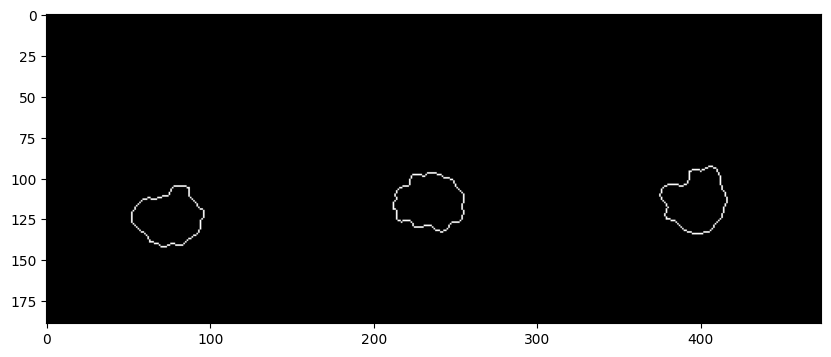

In [131]:
flower_contours = extractContours(flower_binary)
flower_contour_map = createContourMap(background_binary.shape, flower_contours)

plt.figure(figsize=(10, 10))
plt.imshow(flower_contour_map, cmap='grey')

In [132]:
flower_contour_interpolated = interpolateContours(flower_contours, 100)
flower_mean_shape, flower_contours_aligned = processGPA(flower_contour_interpolated)

1.3529400445641477e-07


In [133]:
flower_procrustes_distances = procrustesDistances(flower_mean_shape, flower_contours_aligned)
summarizeData(flower_procrustes_distances, "Procrustes Analysis")

flower_procrustes_distances

DATA SUMMARY of [Procrustes Analysis]:
Num     : 3
Mean    : 0.0644
SD      : 0.0109
SD rel  : 16.91%
Median  : 0.0693
MAD     : 0.0054
MAD rel : 7.80%
Min     : 0.0493
Max     : 0.0747



array([0.04934559, 0.07468828, 0.06928724])

In [134]:
flower_contour_areas = contourAreas(flower_contours)
summarizeData(np.sqrt(flower_contour_areas), "Flowers Rooted Areas")

flower_contour_areas

DATA SUMMARY of [Flowers Rooted Areas]:
Num     : 3
Mean    : 33.4282
SD      : 0.2342
SD rel  : 0.70%
Median  : 33.4963
MAD     : 0.1786
MAD rel : 0.53%
Min     : 33.1134
Max     : 33.6749



array([1096.5, 1134. , 1122. ])

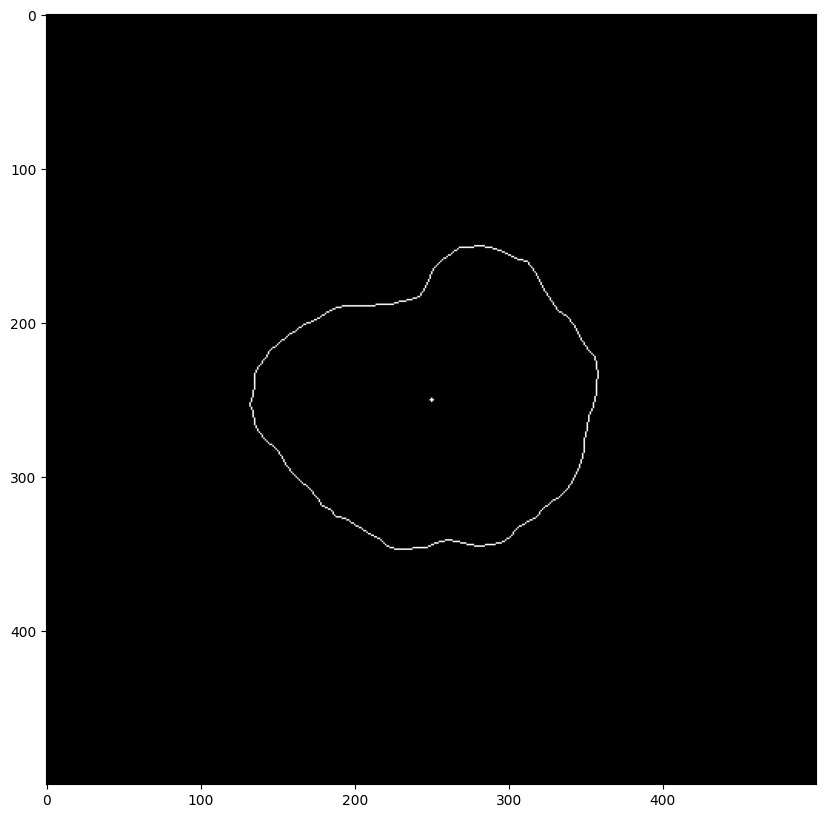

In [135]:
flower_size_factor = 1000

flower_mean_shape_binary = drawStandardizedContour((500, 500), flower_mean_shape, flower_size_factor)

plt.figure(figsize=(10, 10))
plt.imshow(flower_mean_shape_binary, cmap='gray')

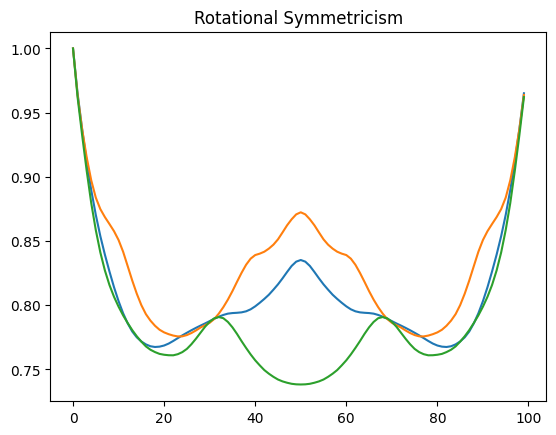

In [136]:
plt.title("Rotational Symmetricism")
for shape in flower_contours_aligned:
    sns.lineplot(testRotationalSymmetry(shape))

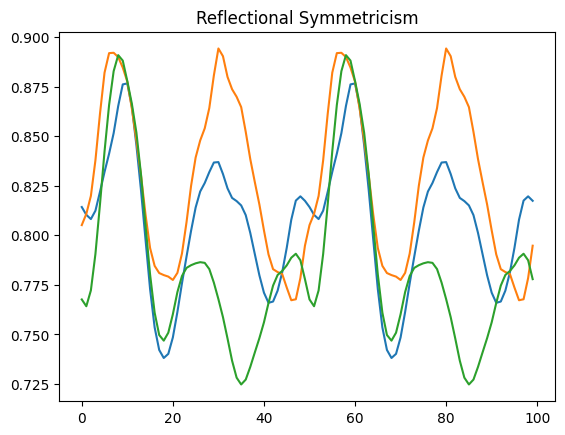

In [137]:
plt.title("Reflectional Symmetricism")
for shape in flower_contours_aligned:
    sns.lineplot(testReflectionalSymmetry(shape))

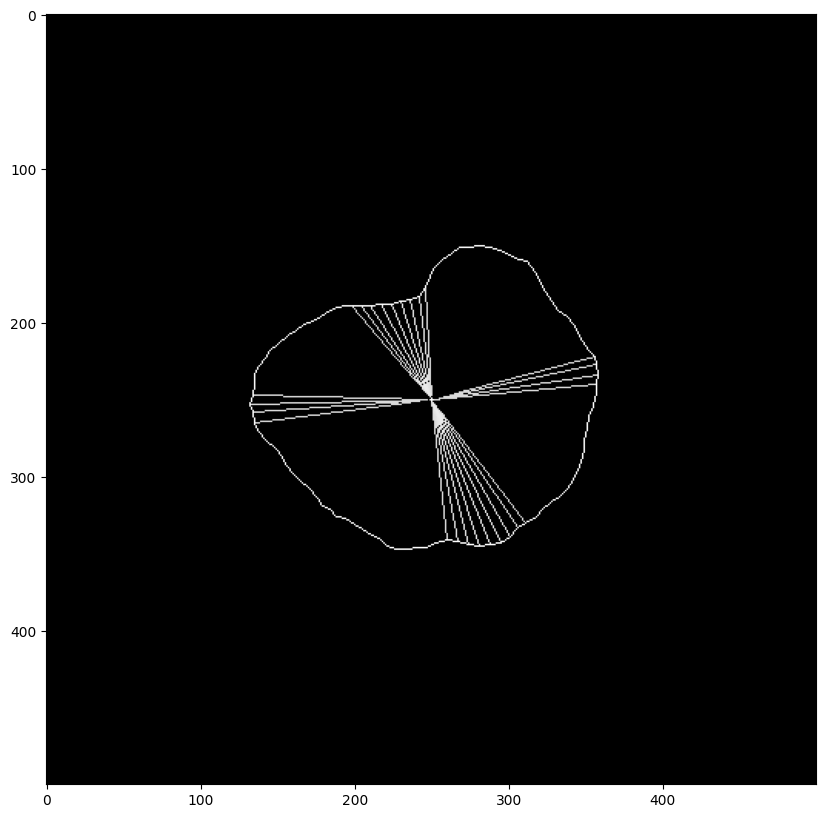

In [138]:
flower_mean_shape_reflectional_symmetry = drawReflectionalSymmetryAxis(
    (500, 500), flower_mean_shape, flower_size_factor, minimum_symmetricity=0.85
)

plt.figure(figsize=(10, 10))
plt.imshow(flower_mean_shape_reflectional_symmetry, cmap='gray')

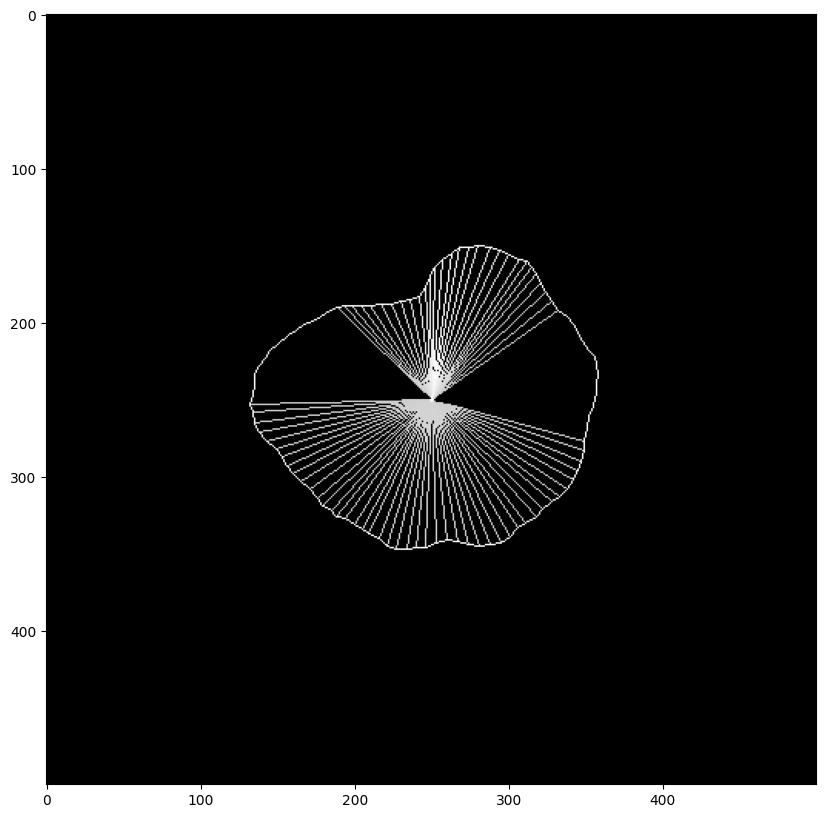

In [139]:
flower_mean_shape_rotational_symmetry = drawRotationalSymmetryAxis(
    (500, 500), flower_mean_shape, flower_size_factor, minimum_symmetricity=0.8
)

plt.figure(figsize=(10, 10))
plt.imshow(flower_mean_shape_rotational_symmetry, cmap='gray')